In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import tqdm
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Currently using {DEVICE}")

Currently using cuda


In [2]:
from src.data_import import load_fashion_mnist, load_mnist_digit, load_CIFAR10

train_loader, test_loader = load_CIFAR10(32, shuffle=True, class_subset=[5])

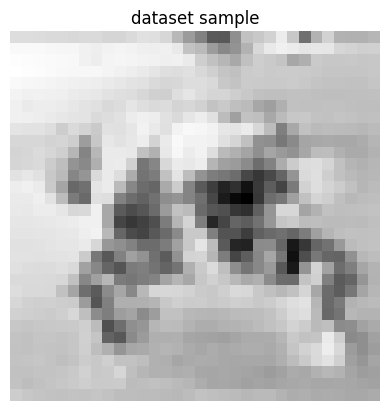

label: 5
torch.Size([32, 1, 32, 32])


In [3]:
from src.plot import show_single_sample, show_grid

x_real, _ = next(iter(train_loader))
show_single_sample(x_real[0], "dataset sample", cmap="Grays")
#print label
print("label:", _[0].item())
print(x_real.shape)

In [ ]:
from src.model import EnergyHead, EBM, SmallEBM

n_heads = 6

model = SmallEBM(in_dim=(1,32,32), mid_dim=150, n_heads=n_heads, batch_size=32)

model.to(DEVICE)

SmallEBM(
  (heads): ModuleList(
    (0-5): 6 x SmallEnergyHead(
      (net): Sequential(
        (0): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1))
        (1): Flatten(start_dim=1, end_dim=-1)
        (2): GELU(approximate='none')
        (3): Linear(in_features=900, out_features=1, bias=True)
      )
    )
  )
)

In [ ]:
from src.sampler import ReplaySampler
from src.information import TotalCorrelationEstimator

sampler = ReplaySampler(model, img_shape=(1, 32, 32), buffer_size=600, noise_fraction=0.05, device=DEVICE)
total_correlation_estimator = TotalCorrelationEstimator(n_heads, hidden_dim=64)
total_correlation_estimator.to(DEVICE)

In [6]:
from src.train import train_one_epoch_TC
#torch.autograd.set_detect_anomaly(True, check_nan=False)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.0, 0.999))

for epoch in range(10):
    epoch_loss = train_one_epoch_TC(

        model, 
        total_correlation_estimator, 
        sampler, 
        train_loader, 
        optimizer,

        sample_steps=30,
        sample_step_size=1.0,
        sample_noise_std=0.005,
        energy_reg=0.5,
        tc_reg=1e-2,

        device=DEVICE
    )
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

  0%|          | 0/157 [00:00<?, ?it/s]


RuntimeError: mat1 and mat2 shapes cannot be multiplied (3x784 and 900x1)

EBM DIAGNOSTICS

[1] Energy on real data
  Train  →  mean=0.0423,  std=0.0736
  Test   →  mean=0.0407,  std=0.0661
  |E_test - E_train| = 0.0017  (ok)

[2] Energy on fake data (Langevin samples)
  Fake   →  mean=-0.1566,  std=0.0127
  Gap (E_real_train - E_fake) = 0.1990  (WARNING: gap inverted)

[3] Energy on pure noise
  Noise  →  mean=1.1647,  std=0.0590
  Gap (E_real_train - E_noise) = -1.1223  (ok)

[4] Per-head energy (on train batch)
  Head 0  →  mean=-0.0162,  std=0.1343
  Head 1  →  mean=-0.1503,  std=0.0128
  Head 2  →  mean=0.1949,  std=0.0985
  Head 3  →  mean=0.4271,  std=0.1675
  Head 4  →  mean=-0.0524,  std=0.0301
  Head 5  →  mean=-0.3511,  std=0.0703
  Max off-diagonal correlation: 0.9831  (WARNING: heads are correlated)

[5] Replay buffer
  Buffer size: 600 / 600
  Buffer samples  →  mean=0.1453,  std=0.3185,  min=-1.0000,  max=1.0000

[6] Visual samples (Langevin from noise)


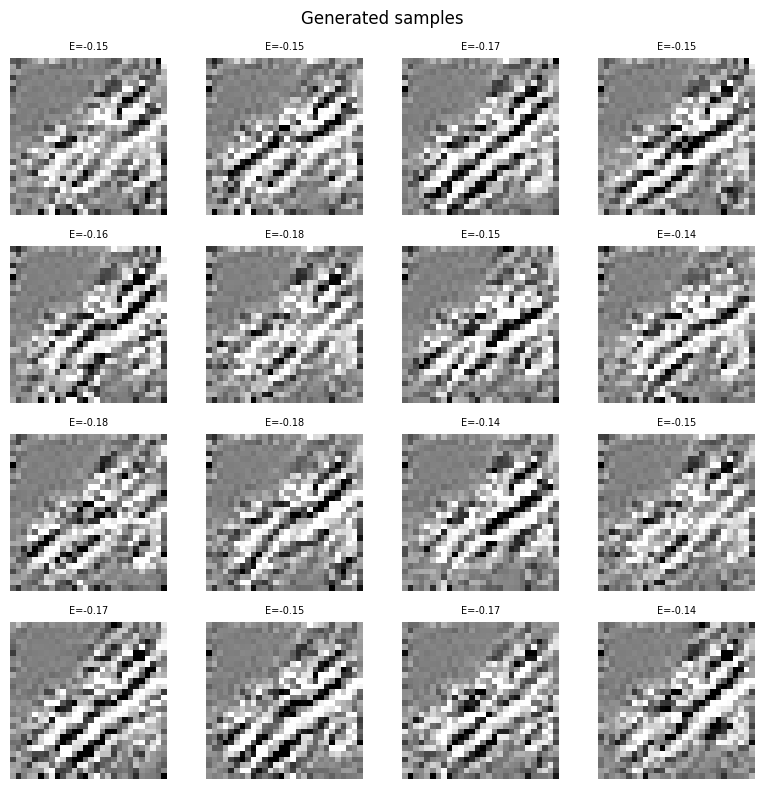


DONE


In [ ]:
from src.diagnostic import diagnose

diagnose(model, sampler, train_loader, test_loader, device=DEVICE, n_samples=16)

In [ ]:
samples = sampler.generate(10, steps=200, step_size=10, noise_std=0.005)

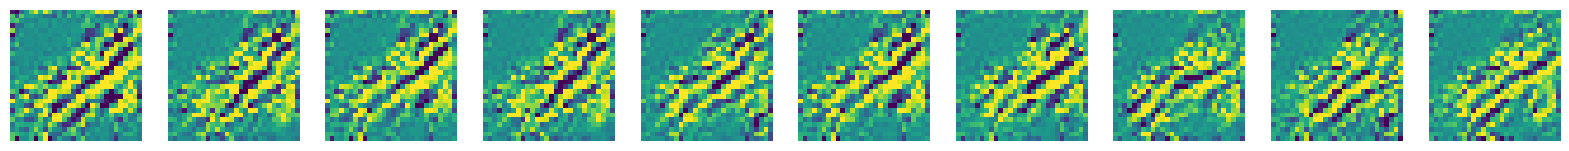

In [ ]:
show_grid(samples, 10)

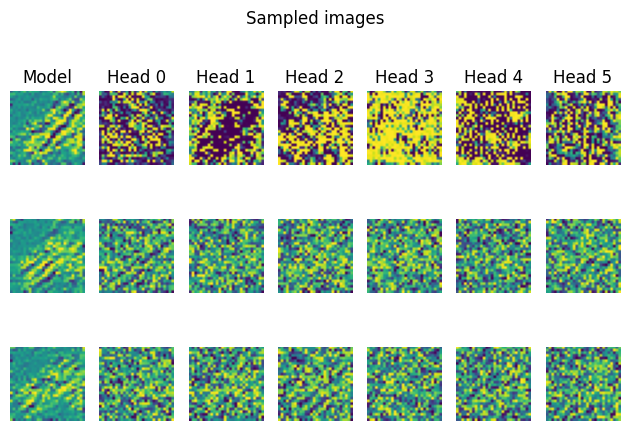

In [ ]:
from src.plot import visualize_heads

fig = visualize_heads(model, sampler.buffer, (1,32,32), DEVICE, k=3, cmap="viridis")

In [ ]:
def visualize_head_gradients(model, x, device, idx=0):
    """
    Per una singola immagine, mostra dE_i/dx per ogni testa.
    Rivela cosa "guarda" ogni testa nell'immagine.
    """
    model.eval()
    img = x[idx].unsqueeze(0).to(device)  # (1, 1, 28, 28)

    n_heads = len(model.heads)
    fig, axes = plt.subplots(1, n_heads + 1, figsize=(3 * (n_heads + 1), 3))

    # Immagine originale
    axes[0].imshow(img.squeeze().cpu().numpy(), cmap="gray")
    axes[0].set_title("Input")
    axes[0].axis("off")

    for i, head in enumerate(model.heads):
        x_ = img.detach().requires_grad_(True)
        with torch.enable_grad():
            e = head(x_).sum()
            g = torch.autograd.grad(e, x_, only_inputs=True)[0]

        g_np = g.squeeze().cpu().detach().numpy()
        g_np = np.abs(g_np)
        g_np = (g_np - g_np.min()) / (g_np.max() - g_np.min() + 1e-8)

        axes[i + 1].imshow(g_np, cmap="hot")
        axes[i + 1].set_title(f"Head {i}\n|dE/dx|")
        axes[i + 1].axis("off")

    plt.suptitle("Gradient maps per testa", fontsize=12)
    plt.tight_layout()
    plt.show()